# Normalised Mutual Information

NMI provides a quantitative assessment of a clustering algotithm's ability to identify meaningful and distinct groups within the data.

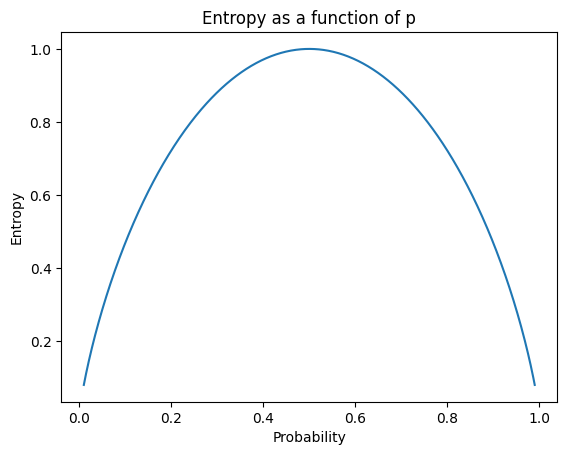

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def entropy(p):
    q = 1 - p
    # The RHS of the expression is
    # for the other classification
    return (-p * np.log2(p)) + (-q * np.log2(q))


# Generate some values for p
ps = np.linspace(0.01, 0.99, 1000)
entropys = entropy(ps)

# Plot these
plt.plot(ps, entropys)
plt.title("Entropy as a function of p")
plt.xlabel("Probability")
plt.ylabel("Entropy")
plt.show()

If $U$ and $V$ are two different sets of labelling for clusters, then we can define their individual entropy as the following:
$$H(U) = - \sum_{i = 1}^{|U|} P(i) \log(P_i)$$
$$H(V) = - \sum_{i = 1}^{|V|} P'(j) \log(P'_j)$$
where $P(i)$ and $P'(j)$ are the probability that an object picked from $U$ and $V$ at random falls at $U_i$ and $V_j$ respectively.

The mutual information (MI) between $U$ and $V$ is calculated by:
$$\text{MI}(U, V) = \sum_{i = 1}^{|U|} \sum_{i = 1}^{|V|} P(i, j) \log\frac{P(i, j)}{P(i)P'(j)}$$
where $P(i, j)$ is the probability that an object picked at random falls into both classes $U_i$ and $V_j$.

$$\text{Normalised MI}(U, V) = \frac{\text{MI}(U, V)}{\text{mean}(H(U), H(V))}$$

In [4]:
# Say we have two labels 1 and 0
cluster_1 = np.array([1, 1, 1, 0])
cluster_2 = np.array([0, 0, 1, 1])

# We want to see what is the agreement between these two


def nmi(cl_1, cl_2):
    joint_proba_matrix = np.zeros((len(np.unique(cl_1)), len(np.unique(cl_2))))

    for i in range(len(cl_1)):
        joint_proba_matrix[cl_1[i], cl_2[i]] += 1

    joint_proba_matrix /= len(cl_1)

    marginal_proba_cl_1 = np.sum(joint_proba_matrix, axis=1)
    marginal_proba_cl_2 = np.sum(joint_proba_matrix, axis=0)

    entropy_cl_1 = -np.sum(marginal_proba_cl_1 * np.log2(marginal_proba_cl_1))
    entropy_cl_2 = -np.sum(marginal_proba_cl_2 * np.log2(marginal_proba_cl_2))

    mutual_info = 0
    for i in range(len(np.unique(cl_2))):
        for j in range(len(np.unique(cl_2))):
            if joint_proba_matrix[i, j] > 0:
                mutual_info += joint_proba_matrix[i, j] * np.log2(
                    joint_proba_matrix[i, j]
                    / (marginal_proba_cl_1[i] * marginal_proba_cl_2[j])
                )

    nmi = mutual_info / ((entropy_cl_1 + entropy_cl_2) / 2)
    return nmi


nmi(cluster_1, cluster_2)

np.float64(0.3437110184854507)

In [3]:
from sklearn.metrics import normalized_mutual_info_score

normalized_mutual_info_score(cluster_1, cluster_2)

0.3437110184854508